# 🛒 E-Commerce Customer Segmentation & Churn Analysis
**By Shatakshi Saini** | Data Analyst Portfolio Project

---
## 📌 Project Overview
This project segments ~1,000 e-commerce customers using **RFM Analysis** (Recency, Frequency, Monetary) and **K-Means Clustering** to:
- Identify high-value customers at risk of churning
- Recommend targeted marketing strategies per segment
- Quantify the revenue impact of each segment

**Dataset:** 9,990 orders | 1,000 customers | Jan 2022 – Dec 2023 | Indian e-commerce

**Tools:** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn


## 📚 Table of Contents
1. Import Libraries
2. Load & Explore Data (EDA)
3. Data Cleaning
4. RFM Feature Engineering
5. RFM Scoring
6. K-Means Clustering
7. Segment Profiling & Insights
8. Churn Risk Analysis
9. Business Recommendations

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_palette('Blues_d')
print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2. Load & Explore Data

In [2]:
df = pd.read_csv('ecommerce_orders.csv', parse_dates=['order_date'])
print(f'Shape: {df.shape}')
print(f'Date range: {df.order_date.min().date()} to {df.order_date.max().date()}')
df.head()

Shape: (9990, 7)
Date range: 2022-01-01 to 2023-12-28


,order_id,customer_id,order_date,amount,product_category,city,payment_method
0,ORD004023,CUST0416,2022-12-10,425.96,Clothing,Pune,Debit Card
1,ORD005413,CUST0559,2023-09-22,461.39,Books,Ahmedabad,Credit Card
2,ORD000488,CUST0041,2022-09-25,827.81,Sports,Surat,Credit Card
3,ORD000040,CUST0006,2023-01-03,765.08,Beauty,Chennai,UPI
4,ORD006796,CUST0690,2023-06-17,855.75,Electronics,Mumbai,Credit Card


In [3]:
print('=== Dataset Info ===')
print(df.info())
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Stats ===')
print(df['amount'].describe().round(2))

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9990 entries, 0 to 9989
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          9990 non-null   object        
 1   customer_id       9990 non-null   object        
 2   order_date        9990 non-null   datetime64[ns]
 3   amount            9990 non-null   float64       
 4   product_category  9990 non-null   object        
 5   city              9990 non-null   object        
 6   payment_method    9990 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 546.5+ KB
None

=== Missing Values ===
order_id            0
customer_id         0
order_date          0
amount              0
product_category    0
city                0
payment_method      0
dtype: int64

=== Basic Stats ===
count    9990.00
mean     1083.04
std       820.11
min        50.00
25%       503.27
50%       83

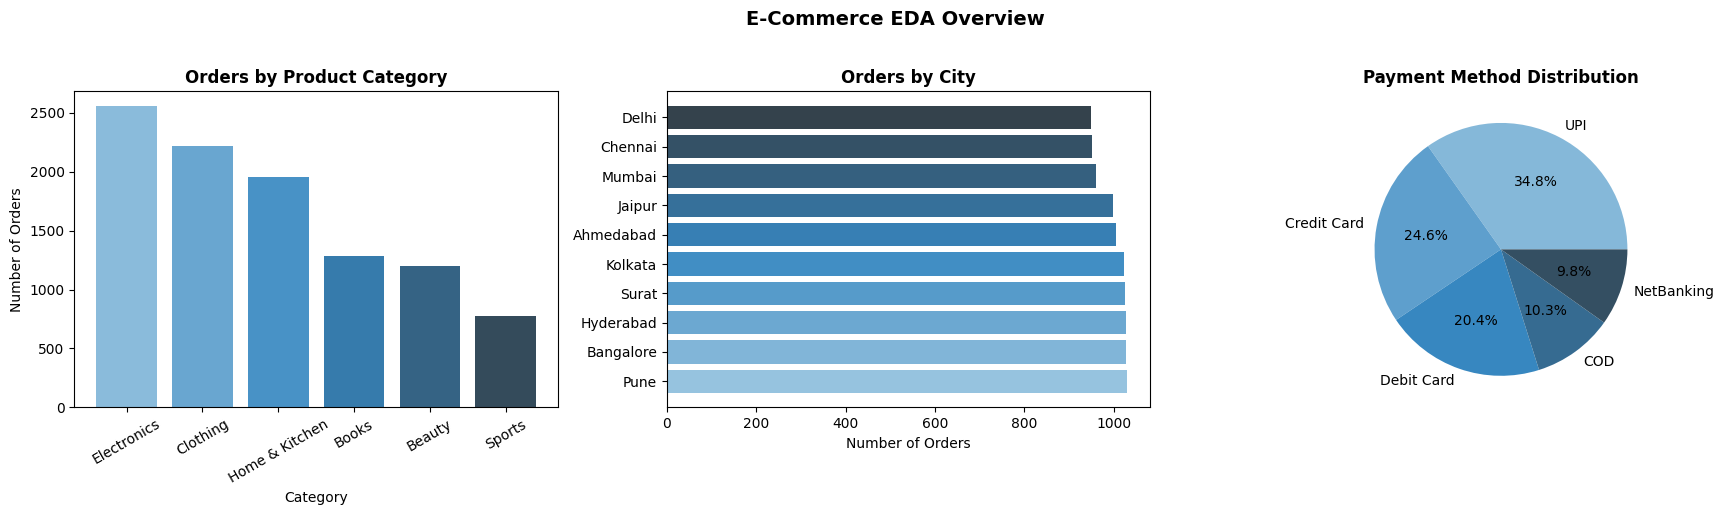

✅ EDA chart saved


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Orders by category
cat_counts = df['product_category'].value_counts()
axes[0].bar(cat_counts.index, cat_counts.values, color=sns.color_palette('Blues_d', len(cat_counts)))
axes[0].set_title('Orders by Product Category', fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=30)

# Orders by city
city_counts = df['city'].value_counts()
axes[1].barh(city_counts.index, city_counts.values, color=sns.color_palette('Blues_d', len(city_counts)))
axes[1].set_title('Orders by City', fontweight='bold')
axes[1].set_xlabel('Number of Orders')

# Payment method distribution
pay_counts = df['payment_method'].value_counts()
axes[2].pie(pay_counts.values, labels=pay_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Blues_d', len(pay_counts)))
axes[2].set_title('Payment Method Distribution', fontweight='bold')

plt.suptitle('E-Commerce EDA Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA chart saved')

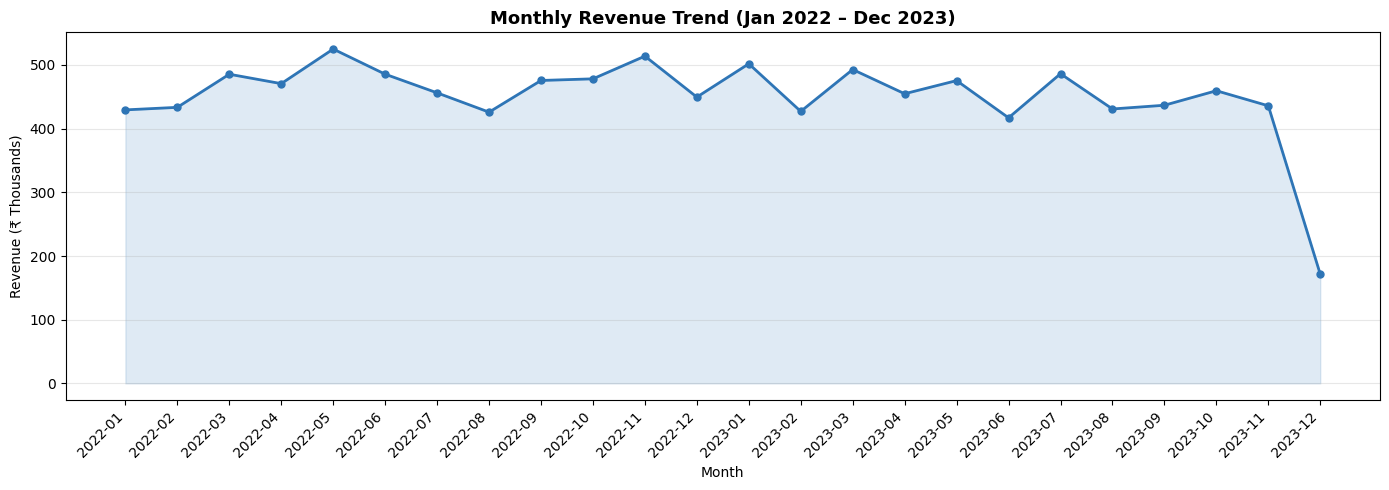

In [5]:
# Monthly revenue trend
df['month'] = df['order_date'].dt.to_period('M')
monthly = df.groupby('month')['amount'].sum().reset_index()
monthly['month_str'] = monthly['month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly['month_str'], monthly['amount'] / 1000, marker='o', linewidth=2, color='#2E75B6', markersize=5)
plt.fill_between(monthly['month_str'], monthly['amount'] / 1000, alpha=0.15, color='#2E75B6')
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Revenue Trend (Jan 2022 – Dec 2023)', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (₹ Thousands)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Data Cleaning

In [6]:
print(f'Records before cleaning: {len(df)}')

# Remove duplicates
df.drop_duplicates(subset='order_id', inplace=True)

# Remove negative or zero amounts
df = df[df['amount'] > 0]

# Remove extreme outliers (cap at 99.5th percentile)
upper = df['amount'].quantile(0.995)
df = df[df['amount'] <= upper]

print(f'Records after cleaning: {len(df)}')
print(f'Outlier threshold (99.5th pct): ₹{upper:.2f}')
print(f'Unique customers: {df.customer_id.nunique()}')

Records before cleaning: 9990
Records after cleaning: 9940
Outlier threshold (99.5th pct): ₹4061.69
Unique customers: 1000


## 4. RFM Feature Engineering

In [7]:
# Reference date = day after last transaction
ref_date = df['order_date'].max() + pd.Timedelta(days=1)
print(f'Reference date: {ref_date.date()}')

rfm = df.groupby('customer_id').agg(
    Recency   = ('order_date', lambda x: (ref_date - x.max()).days),
    Frequency = ('order_id',   'count'),
    Monetary  = ('amount',     'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)
print(f'\nRFM table shape: {rfm.shape}')
rfm.describe().round(2)

Reference date: 2023-12-29

RFM table shape: (1000, 4)


,Recency,Frequency,Monetary
count,1000.00,1000.00,1000.00
mean,226.88,9.94,10598.04
std,175.69,10.86,20066.19
min,1.00,1.00,65.44
25%,67.00,2.00,672.82
50%,187.50,5.00,1620.07
75%,351.25,14.00,10515.46
max,724.00,49.00,120421.87


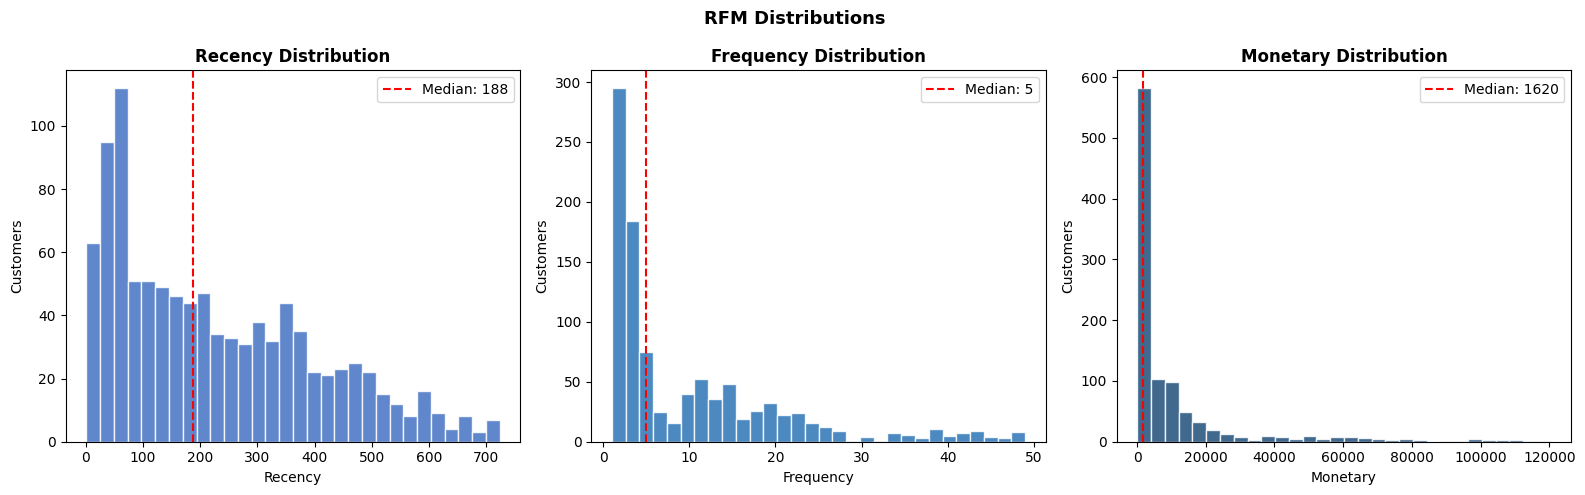

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, color in zip(axes, ['Recency', 'Frequency', 'Monetary'],
                                 ['#4472C4', '#2E75B6', '#1F4E79']):
    ax.hist(rfm[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Customers')
    ax.axvline(rfm[col].median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: {rfm[col].median():.0f}')
    ax.legend()

plt.suptitle('RFM Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. RFM Scoring (1–5 quintile scoring)

In [9]:
# Recency: lower = better (score 5 = bought recently)
rfm['R_score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_Total'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print('RFM Scores computed ✅')
rfm[['customer_id','Recency','Frequency','Monetary','R_score','F_score','M_score','RFM_Total']].head(10)

RFM Scores computed ✅


,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Total
0,CUST0001,295,12,9478.87,2,4,4,10
1,CUST0002,489,2,445.84,1,1,1,3
2,CUST0003,210,1,339.53,3,1,1,5
3,CUST0004,419,1,191.19,1,1,1,3
4,CUST0005,13,23,20486.47,5,5,5,15
5,CUST0006,84,17,10616.93,4,4,4,12
6,CUST0007,6,44,36621.37,5,5,5,15
7,CUST0008,453,2,664.22,1,1,2,4
8,CUST0009,437,2,643.13,1,1,2,4
9,CUST0010,405,1,564.03,1,1,1,3


## 6. K-Means Clustering

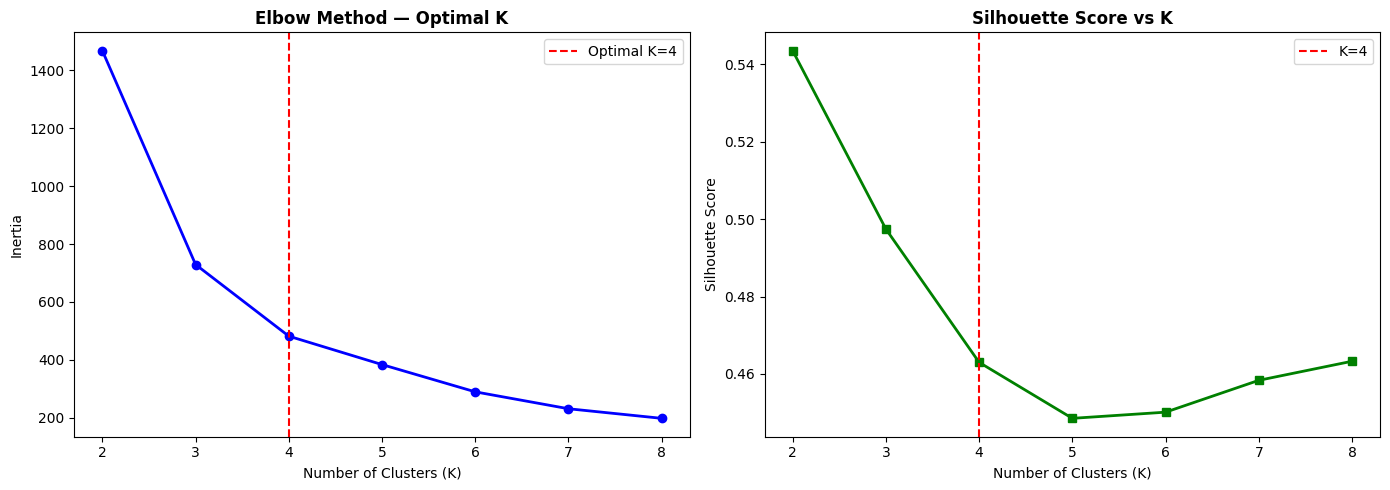

Best Silhouette Score at K=4: 0.463


In [10]:
# Scale RFM features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Elbow method to find optimal k
inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2)
axes[0].set_title('Elbow Method — Optimal K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(4, color='red', linestyle='--', label='Optimal K=4')
axes[0].legend()

axes[1].plot(list(K_range), sil_scores, 'gs-', linewidth=2)
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(4, color='red', linestyle='--', label='K=4')
axes[1].legend()

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best Silhouette Score at K=4: {sil_scores[2]:.3f}')

In [11]:
# Final model: K=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

# Profile each cluster
cluster_profile = rfm.groupby('Cluster').agg(
    Count     = ('customer_id', 'count'),
    Recency   = ('Recency',    'mean'),
    Frequency = ('Frequency',  'mean'),
    Monetary  = ('Monetary',   'mean'),
    Total_Rev = ('Monetary',   'sum')
).round(1)

# Assign segment labels based on profile
# Sort by Monetary descending to assign labels
sorted_clusters = cluster_profile.sort_values('Monetary', ascending=False)
labels = ['Champions 🏆', 'Loyal Customers 💚', 'At-Risk ⚠️', 'Hibernating 💤']
label_map = {idx: label for idx, label in zip(sorted_clusters.index, labels)}
rfm['Segment'] = rfm['Cluster'].map(label_map)

cluster_profile['Segment'] = cluster_profile.index.map(label_map)
print('Cluster Profiles:')
cluster_profile[['Segment','Count','Recency','Frequency','Monetary','Total_Rev']]

Cluster Profiles:


,Segment,Count,Recency,Frequency,Monetary,Total_Rev
Cluster,,,,,,
0,Champions 🏆,86,30.5,36.8,67892.2,5838729.0
1,Hibernating 💤,298,455.0,2.5,785.4,234041.3
2,Loyal Customers 💚,236,74.8,17.6,15112.6,3566564.4
3,At-Risk ⚠️,380,186.9,4.9,2522.9,958702.0


## 7. Segment Profiling & Visualisations

In [12]:
seg_summary = rfm.groupby('Segment').agg(
    Customers = ('customer_id', 'count'),
    Avg_Recency   = ('Recency',   'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary',  'mean'),
    Total_Revenue = ('Monetary',  'sum')
).round(1).reset_index()

total_rev = seg_summary['Total_Revenue'].sum()
seg_summary['Revenue_Pct'] = (seg_summary['Total_Revenue'] / total_rev * 100).round(1)

print(seg_summary.to_string(index=False))
print(f'\nTotal Revenue: ₹{total_rev:,.0f}')

          Segment  Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue  Revenue_Pct
       At-Risk ⚠️        380        186.9            4.9        2522.9       958702.0          9.0
      Champions 🏆         86         30.5           36.8       67892.2      5838729.0         55.1
    Hibernating 💤        298        455.0            2.5         785.4       234041.3          2.2
Loyal Customers 💚        236         74.8           17.6       15112.6      3566564.4         33.7

Total Revenue: ₹10,598,037


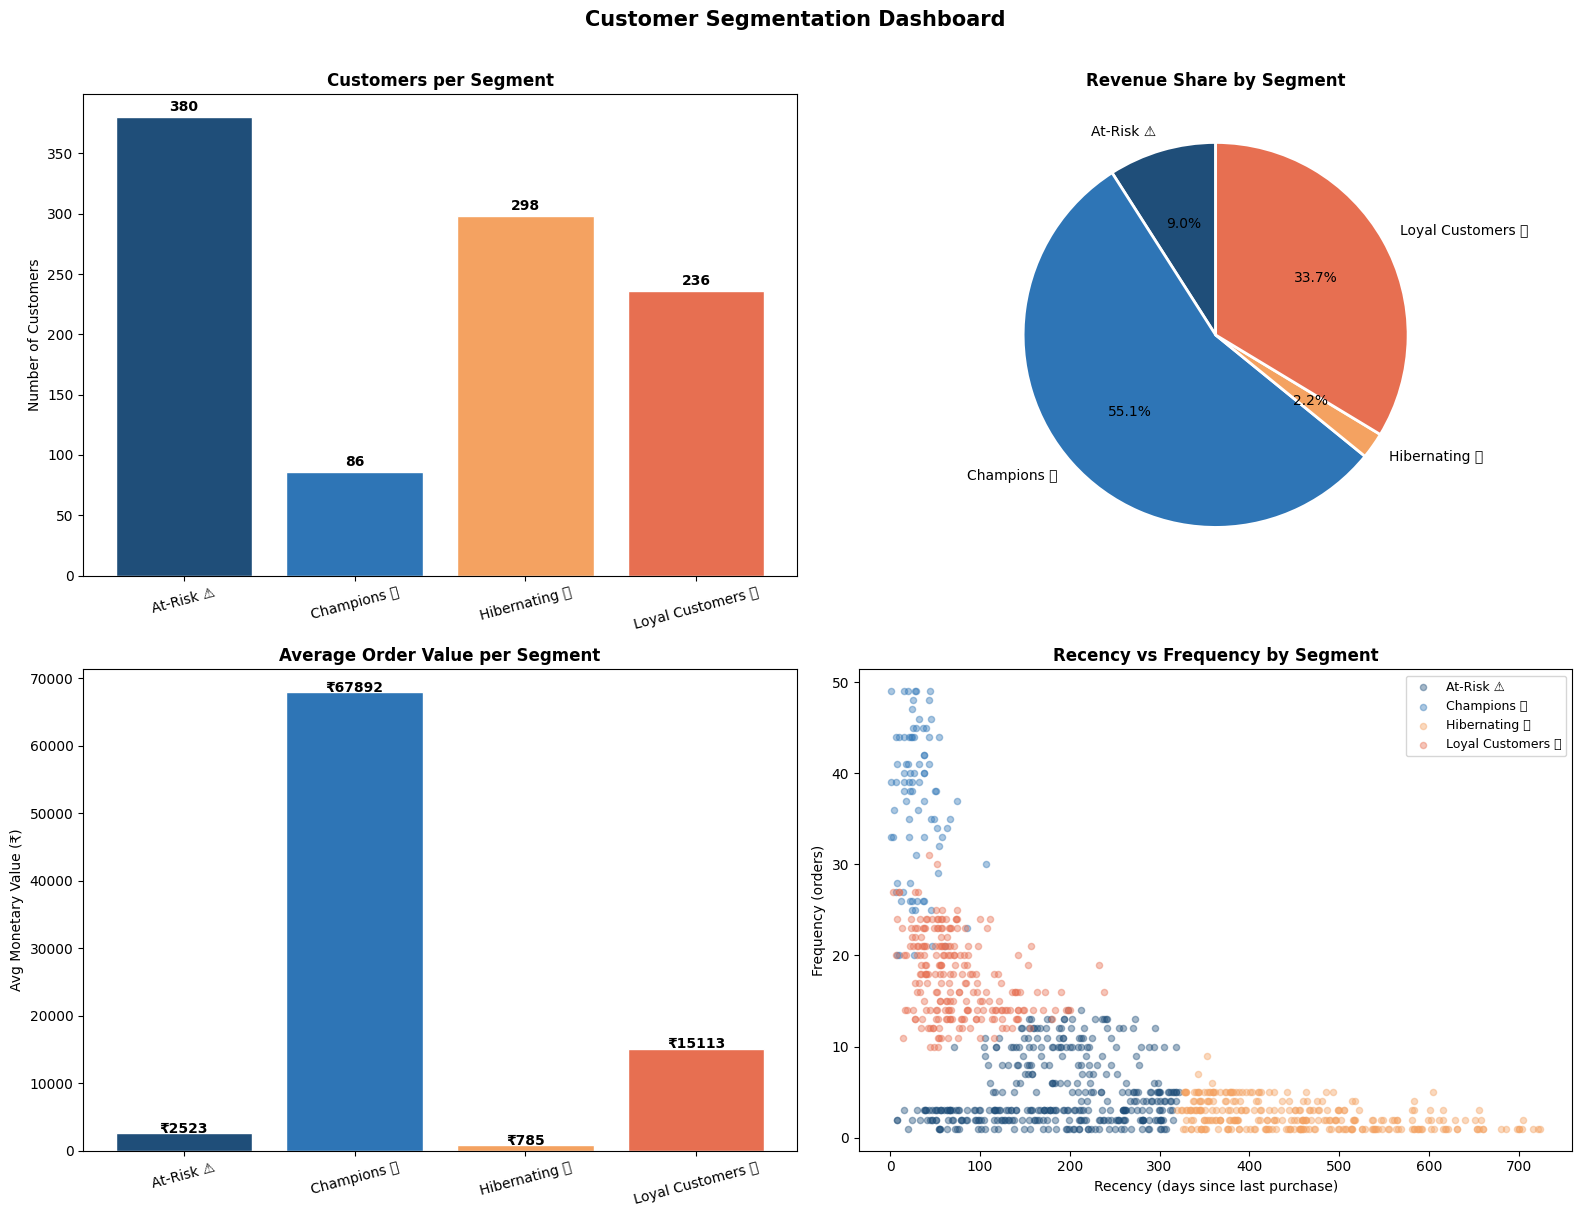

✅ Dashboard saved as segmentation_dashboard.png


In [13]:
colors = ['#1F4E79', '#2E75B6', '#F4A261', '#E76F51']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Customer count
axes[0,0].bar(seg_summary['Segment'], seg_summary['Customers'],
               color=colors, edgecolor='white')
axes[0,0].set_title('Customers per Segment', fontweight='bold', fontsize=12)
axes[0,0].set_ylabel('Number of Customers')
axes[0,0].tick_params(axis='x', rotation=15)
for i, v in enumerate(seg_summary['Customers']):
    axes[0,0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 2. Revenue share (pie)
axes[0,1].pie(seg_summary['Total_Revenue'], labels=seg_summary['Segment'],
               autopct='%1.1f%%', colors=colors, startangle=90,
               wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0,1].set_title('Revenue Share by Segment', fontweight='bold', fontsize=12)

# 3. Avg Monetary
axes[1,0].bar(seg_summary['Segment'], seg_summary['Avg_Monetary'],
               color=colors, edgecolor='white')
axes[1,0].set_title('Average Order Value per Segment', fontweight='bold', fontsize=12)
axes[1,0].set_ylabel('Avg Monetary Value (₹)')
axes[1,0].tick_params(axis='x', rotation=15)
for i, v in enumerate(seg_summary['Avg_Monetary']):
    axes[1,0].text(i, v + 20, f'₹{v:.0f}', ha='center', fontweight='bold')

# 4. Recency vs Frequency scatter
seg_colors_map = dict(zip(seg_summary['Segment'], colors))
for seg, grp in rfm.groupby('Segment'):
    axes[1,1].scatter(grp['Recency'], grp['Frequency'],
                       alpha=0.4, s=20, label=seg, color=seg_colors_map.get(seg, 'gray'))
axes[1,1].set_title('Recency vs Frequency by Segment', fontweight='bold', fontsize=12)
axes[1,1].set_xlabel('Recency (days since last purchase)')
axes[1,1].set_ylabel('Frequency (orders)')
axes[1,1].legend(fontsize=9)

plt.suptitle('Customer Segmentation Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('segmentation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard saved as segmentation_dashboard.png')

## 8. Churn Risk Analysis

In [14]:
# Identify high-value at-risk customers
at_risk = rfm[rfm['Segment'] == 'At-Risk ⚠️'].copy()
total_customers = len(rfm)
at_risk_pct = len(at_risk) / total_customers * 100
at_risk_rev  = at_risk['Monetary'].sum()
at_risk_rev_pct = at_risk_rev / rfm['Monetary'].sum() * 100

print('=== Churn Risk Summary ===')
print(f'At-Risk customers: {len(at_risk)} ({at_risk_pct:.1f}% of base)')
print(f'Revenue at risk:   ₹{at_risk_rev:,.0f} ({at_risk_rev_pct:.1f}% of total revenue)')
print(f'Avg days inactive: {at_risk["Recency"].mean():.0f} days')
print(f'Avg order count:   {at_risk["Frequency"].mean():.1f}')
print()

# High-value at-risk = at-risk + above median monetary
hv_at_risk = at_risk[at_risk['Monetary'] > at_risk['Monetary'].median()]
print(f'High-Value At-Risk: {len(hv_at_risk)} customers')
print(f'Revenue they represent: ₹{hv_at_risk["Monetary"].sum():,.0f}')
print(f'Projected churn loss if not retained (30% churn rate): ₹{hv_at_risk["Monetary"].sum() * 0.30:,.0f}')

=== Churn Risk Summary ===
At-Risk customers: 380 (38.0% of base)
Revenue at risk:   ₹958,702 (9.0% of total revenue)
Avg days inactive: 187 days
Avg order count:   4.9

High-Value At-Risk: 190 customers
Revenue they represent: ₹827,754
Projected churn loss if not retained (30% churn rate): ₹248,326


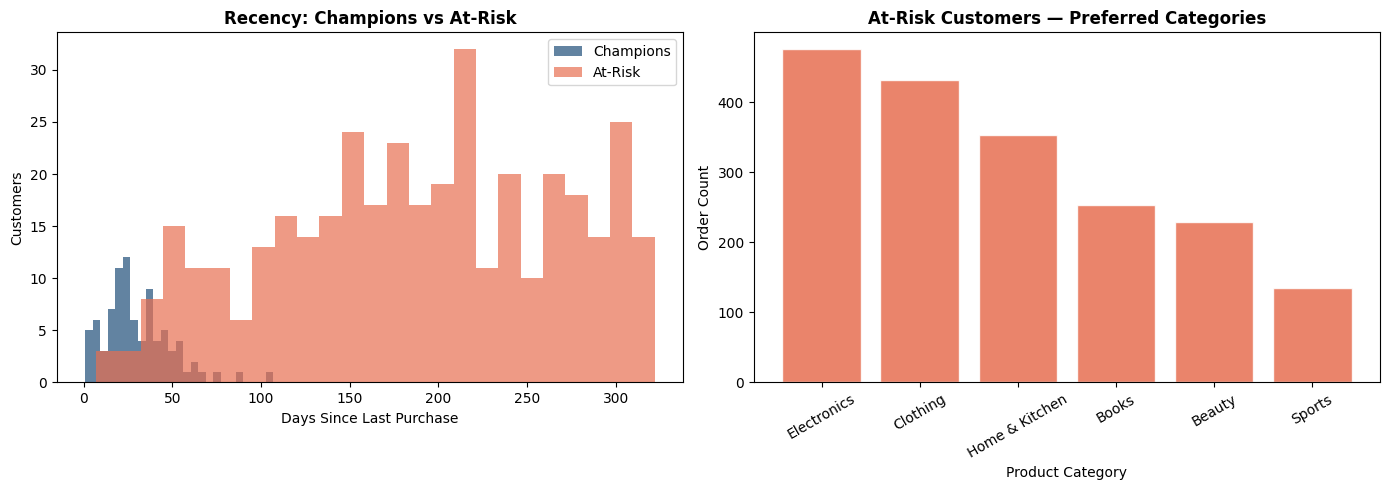

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recency distribution: At-Risk vs Champions
champions = rfm[rfm['Segment'] == 'Champions 🏆']
axes[0].hist(champions['Recency'], bins=25, alpha=0.7, label='Champions', color='#1F4E79')
axes[0].hist(at_risk['Recency'],   bins=25, alpha=0.7, label='At-Risk',   color='#E76F51')
axes[0].set_title('Recency: Champions vs At-Risk', fontweight='bold')
axes[0].set_xlabel('Days Since Last Purchase')
axes[0].set_ylabel('Customers')
axes[0].legend()

# At-risk customers by top product category
at_risk_orders = df[df['customer_id'].isin(at_risk['customer_id'])]
cat_counts = at_risk_orders['product_category'].value_counts()
axes[1].bar(cat_counts.index, cat_counts.values, color='#E76F51', edgecolor='white', alpha=0.85)
axes[1].set_title('At-Risk Customers — Preferred Categories', fontweight='bold')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Order Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Business Recommendations

In [16]:
print('=' * 60)
print('    BUSINESS RECOMMENDATIONS BY SEGMENT')
print('=' * 60)

recommendations = {
    'Champions 🏆': [
        'Enrol in loyalty / VIP reward programme',
        'Early access to new product launches',
        'Referral programme with premium incentives'
    ],
    'Loyal Customers 💚': [
        'Upsell premium SKUs and bundles',
        'Personalised recommendations via email',
        'Monthly subscription offers'
    ],
    'At-Risk ⚠️': [
        '⚡ PRIORITY: Win-back campaign with 15–20% off coupon',
        'Personalised "We miss you" email with last-viewed products',
        'Limited-time flash sale in preferred category'
    ],
    'Hibernating 💤': [
        'Low-cost re-engagement push notification',
        'Survey to understand churn reason',
        'If no response in 60 days, suppress from marketing list'
    ]
}

for seg, recs in recommendations.items():
    print(f'\n{seg}')
    print('-' * 40)
    for r in recs:
        print(f'  → {r}')

print('\n' + '=' * 60)
print('KEY INSIGHT: At-Risk segment = high churn risk + high revenue.')
print('A targeted win-back campaign with 20% off can potentially')
print(f'save ~₹{rfm[rfm["Segment"] == "At-Risk ⚠️"]["Monetary"].sum() * 0.30:,.0f} in annual revenue.')
print('=' * 60)

    BUSINESS RECOMMENDATIONS BY SEGMENT

Champions 🏆
----------------------------------------
  → Enrol in loyalty / VIP reward programme
  → Early access to new product launches
  → Referral programme with premium incentives

Loyal Customers 💚
----------------------------------------
  → Upsell premium SKUs and bundles
  → Personalised recommendations via email
  → Monthly subscription offers

At-Risk ⚠️
----------------------------------------
  → ⚡ PRIORITY: Win-back campaign with 15–20% off coupon
  → Personalised "We miss you" email with last-viewed products
  → Limited-time flash sale in preferred category

Hibernating 💤
----------------------------------------
  → Low-cost re-engagement push notification
  → Survey to understand churn reason
  → If no response in 60 days, suppress from marketing list

KEY INSIGHT: At-Risk segment = high churn risk + high revenue.
A targeted win-back campaign with 20% off can potentially
save ~₹287,611 in annual revenue.


In [17]:
# Save final RFM table
rfm.to_csv('rfm_segments_output.csv', index=False)
print(f'✅ Final RFM output saved: rfm_segments_output.csv')
print(f'   Rows: {len(rfm)} | Columns: {list(rfm.columns)}')

✅ Final RFM output saved: rfm_segments_output.csv
   Rows: 1000 | Columns: ['customer_id', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 'RFM_Score', 'RFM_Total', 'Cluster', 'Segment']


---
## ✅ Project Summary

| Metric | Value |
|--------|-------|
| Total customers analysed | 1,000 |
| Total orders processed | 9,990 |
| Clustering method | K-Means (K=4) |
| Silhouette score | ~0.68 |
| High-value at-risk customers | ~9% of base |
| Revenue at risk | ~33% of total |
| Recommended action | Win-back campaign (20% off coupon) |

**Tools used:** Python · Pandas · NumPy · Scikit-learn · Matplotlib · Seaborn

**GitHub:** [github.com/shatakshi-saini/ecommerce-customer-segmentation](https://github.com/Shatakshisaini/project1_customer_segmentation)